# Beyond clonal data: spatial clustering of genes

As we show in the manuscript, clone2vec is in general a model that provides a robust distance measure between discrete distributions. On top of that, there is no requirement for all elements to exist in the same space. In other word, we can use neighbourhood matrices from completely different experiments if they consists of the same classes of elements.

To illustrate the ability of clone2vec to be used in other settings, we will build a clustering of genes depending on their spatial distribution in single cells using SeqFISH+ data. It's important to keep in mind that we have to assume that every single cell is from the same cell type (which is true for the data we work with), otherwise there is a chance that we can see clusters of genes that are associated with one or another cell type. 

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse as sp
import matplotlib.pyplot as plt
import sclitr as sl

sc.set_figure_params(dpi=80)
sc.settings.verbosity = 3
sns.set_style("ticks")

## Step 1: Downloading and reading the data

Here we will create an AnnData object where instead of cells we will keep every detected RNA molecule as rows.

In [ ]:
!wget https://github.com/jadexq/ELLA/releases/download/v0.0.1/seqfish_data_dict.pkl

data = pd.read_pickle("seqfish_data_dict.pkl")
adata = sc.AnnData(
    X=sp.csc_matrix(np.zeros(len(data["expr"]))[:, None]),
    obs=pd.DataFrame({
        "gene": data["expr"].gene.values,
        "cell": data["expr"].cell.values,
    }, index=data["expr"].index.astype(str)),
    obsm={"X_spatial": data["expr"][["x", "y"]].values},
)

## Step 2: Building a k-NN graphs

Now we need to build a kNN graph between molecules in single cells. To translate it onto a "clonal" language, now cells are individual measurments of RNA molecules, and clones are gene labels of these molecules. Out goal will be to find a genes that spatially co-exist together.

In [6]:
genes = sl.pp.clones_adata(adata, obs_name="gene", fill_obs="cell", min_size=10)

# Putting gene x cell matrix in genes.X
genes.X = sp.csr_matrix(genes.layers["counts"])
genes.layers = {}

# Putting the number of 
genes.var["n_genes"] = genes.X.sum(axis=0).A[0]
genes = genes[:, genes.var.n_genes > 0].copy()

creating clone-level AnnData
    selected 6125 clones (>= 10)
    finished (0:00:09): created clones AnnData with
     .X float matrix of proportions (clones × categories)
     .layers['proportions'] float matrix with fate proportions
     .layers['counts'] integer matrix with fate counts
     .obs['n_cells'] integer vector with number of cells per clone
     .obs['n_fates'] integer vector with number of fates per clone
     .var['n_clones'] integer vector with number of clones per fate
     .uns['fill_obs'] string label


To build graph for each cell independently, we have to add a `split_by` argument.

In [5]:
sl.tl.clonal_nn(adata, genes, split_by="cell", use_rep="X_spatial")

computing clone-to-clone adjacency graph
    split-by 'cell': 100%|██████████| 171/171 [22:29<00:00,  7.89s/it]
    finished (0:22:36): added
     .obsp['gex_adjacency'] clone adjacency graph.
     .uns['clonal_nn'] parameters.


## Step 3: Building an embedding

Now, when we have a matrix of nearest neighbors of each gene, we can create an embedding of these genes. In this case, we will use our fast Poisson model to save a computational time: Poisson model's complexity is $\mathcal{O}(n_\mathrm{genes})$, while classical multinomial model's complexity is $\mathcal{O}(n_\mathrm{molecules})$.

In [76]:
sl.tl.clone2vec_Poi(genes, tol=1e-6, init="random")

fitting clone2vec_Poi embeddings
    GLM-PCA epochs:   9%|▉         | 45/500 [00:29<04:58,  1.52it/s, Log-Likelihood=107853896.0000, Δ=2.97e-07, LR=3.12e-02]
    finished (0:00:29): added
     .obsm['clone2vec_Poi'] embedding matrix
     .uns['clone2vec_Poi'] training details


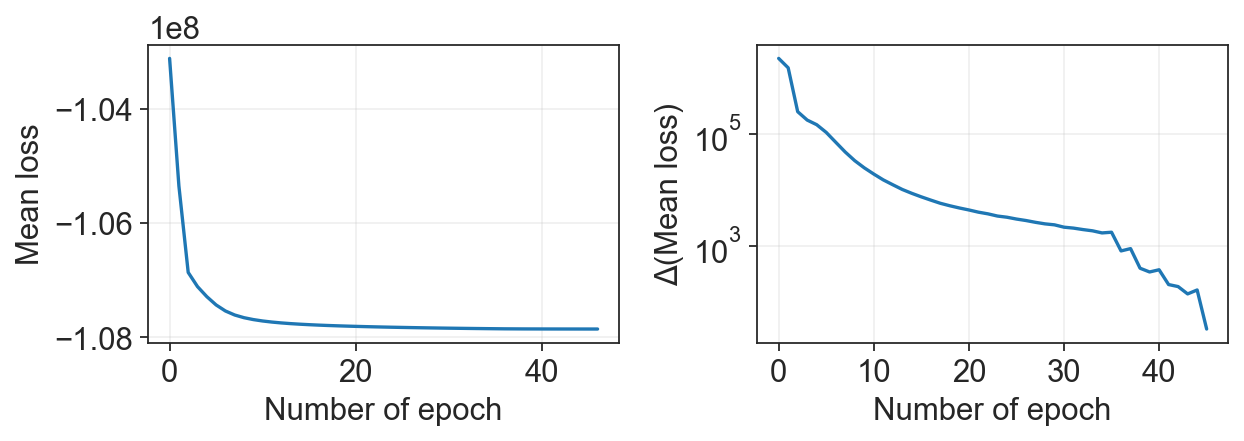

In [8]:
sl.pl.loss_history(genes)

In [78]:
sc.pp.neighbors(genes, use_rep="clone2vec_Poi")

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)


In [79]:
sc.tl.umap(genes)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:08)


In [80]:
sc.tl.leiden(
    genes,
    resolution=0.25,
    flavor="igraph",
    n_iterations=2,
)

running Leiden clustering
    finished: found 3 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


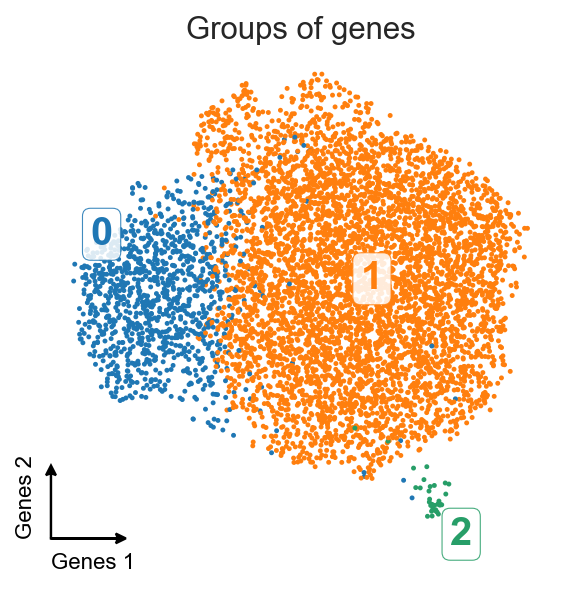

In [10]:
ax = sc.pl.umap(
    genes, 
    color="leiden",
    frameon=False,
    title="Groups of genes",
    show=False,
)

sl.pl.fancy_legend(ax, center_loc=False, textsize=18, fontweight="bold")
sl.pl.embedding_axis(ax, label="Genes")

Here we got three clusters of genes. Let's check what are these genes.

In [82]:
top_n = 10

print(f"Top-{top_n} genes from")
for leiden in ["0", "1", "2"]:
    top_genes = genes[genes.obs.leiden == leiden].obs.sort_values("n_cells", ascending=False).index[:top_n]
    print(f"   cluster {leiden}: {', '.join(top_genes)}")

Top-10 genes from
   cluster 0: Col1a1, Fn1, Bgn, Emp1, Lox, Fbln2, Flna, P4hb, Col6a2, Nid1
   cluster 1: Myh9, Hnrnpf, Tagln2, Ddb1, Actn1, Pcbp1, Fscn1, Kpnb1, Hnrnpl, Ppp1ca
   cluster 2: Cyb5r3, Kctd10, Dynll2, Sh3pxd2a, Ddr2, Palld, Naa50, Dync1li2, Kif1c, Zcchc24


Genes from cluster 0 look like genes that cell is usually secreting into intercellular space, therefore they're usually processed in the EPR and contain SRP signal. Genes from cluster 1 are house-keeping genes, and their localization should not be linked to EPR (further away from the nuclei). And the genes from cluster 2 are genes that usually are being transported to protrusions.

Let's validate it visually.

## Step 4: Plotting of groups of genes

In [11]:
genes_mapping = dict(genes.obs.leiden)
adata.obs["group"] = [genes_mapping[i] if i in genes_mapping else "NA" for i in adata.obs.gene]

/home/sergey/miniconda3/envs/sl/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


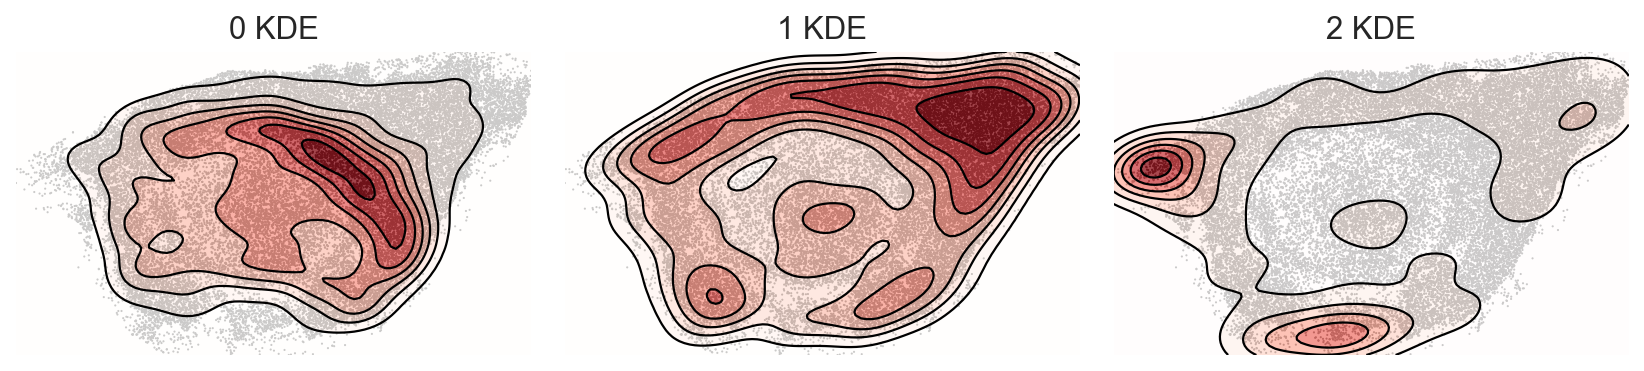

In [12]:
cell = "5-0"

sl.pl.group_kde(
    adata[adata.obs.cell == cell],
    groupby="group",
    groups=["0", "1", "2"],
    basis="X_spatial",
    bw_method=0.2,
)

Here we see that our initial guess was correct, and localization of these groups of genes matches our prediction. It's also consistent with the results that authors obtained in [the original paper](https://www.nature.com/articles/s41586-019-1049-y).

## Step 5: Checking SRP

Additionally, we can check an SRP signal distribution across clusters based on the prediction of SRP via [DeepSig](https://academic.oup.com/bioinformatics/article/34/10/1690/4769493).

### Step 5.1: Downloading and filtering proteome

Here we will download fasta-file with mouse proteome and keep only proteins from the analysis.

```bash
mkdir deepsig
cd deepsig
wget https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_mouse/release_M38/gencode.vM38.pc_translations.fa.gz
gunzip gencode.vM38.pc_translations.fa.gz
mv gencode.vM38.pc_translations.fa mm_proteins.fa
```

In [31]:
# Helpers to work with fasta

def fasta_to_dict(path):
    seqs = {}
    current_id = None
    current_seq = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if current_id is not None:
                    seqs[current_id] = "".join(current_seq)
                current_id = line[1:]
                current_seq = []
            else:
                current_seq.append(line)
        if current_id is not None:
            seqs[current_id] = "".join(current_seq)
    return seqs

def dict_to_fasta(seq_dict, path, line_width=80):
    with open(path, "w") as f:
        for seq_id, seq in seq_dict.items():
            f.write(f">{seq_id}\n")
            for i in range(0, len(seq), line_width):
                f.write(seq[i:(i + line_width)] + "\n")

In [29]:
fasta = fasta_to_dict("deepsig/mm_proteins.fa")

filtered_fasta = {}
for record in fasta:
    gene_name = record.split("|")[-2]
    if gene_name in genes.obs_names:
        if gene_name not in filtered_fasta:
            filtered_fasta[gene_name] = fasta[record]
        elif len(filtered_fasta[gene_name]) < len(fasta[record]):
            filtered_fasta[gene_name] = fasta[record]

dict_to_fasta(filtered_fasta, "deepsig/mm_filtered.fa")

### Strp 5.2: DeepSig

```bash
docker pull bolognabiocomp/deepsig
docker run -v $(pwd):/data/ bolognabiocomp/deepsig -f mm_filtered.fa -o mm.out -k euk
```

In [65]:
deepsig = pd.read_csv(
    "deepsig/mm.out",
    sep="\t",
    names=["gene", "0", "prediction", "1", "2", "3", "4", "5", "6"],
    usecols=["gene", "prediction"],
)

srp_genes = set(deepsig[deepsig.prediction == "Signal peptide"].gene.values)
all_genes = set(deepsig.gene.values)

genes.obs["srp"] = [
    "True" if i in srp_genes
    else "False" if i in all_genes
    else np.nan for i in genes.obs_names
]

Plotting these genes on UMAP.

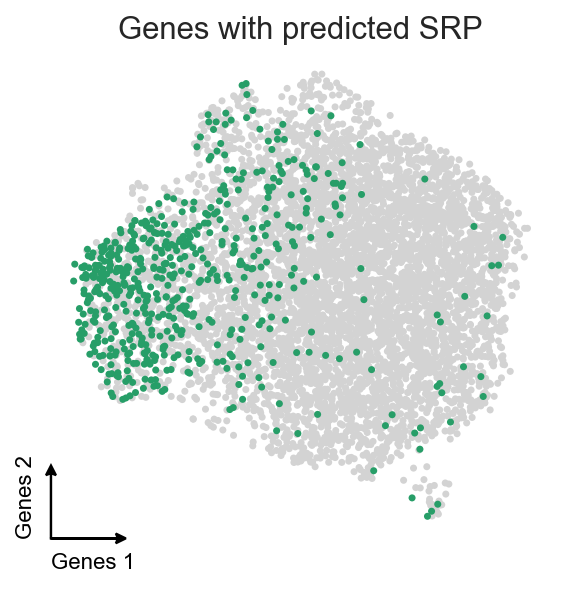

In [16]:
ax = sc.pl.umap(
    genes,
    color="srp",
    groups=["True"],
    legend_loc=None,
    frameon=False,
    title="Genes with predicted SRP",
    show=False,
    s=40,
    palette={
        "True": sns.color_palette()[2],
        "False": sns.color_palette()[3],
    },
)

sl.pl.embedding_axis(ax, label="Genes")

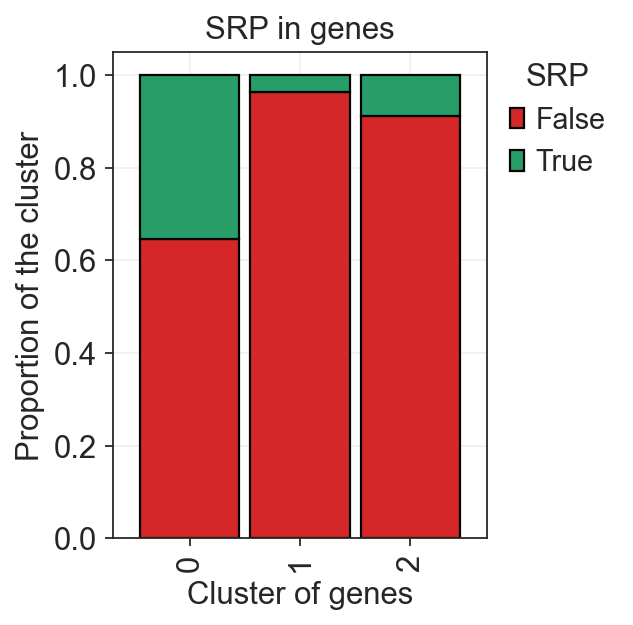

In [13]:
composition = genes.obs[genes.obs.srp != np.nan].groupby(
    ["leiden", "srp"], observed=True
).size().unstack()

fig, ax = plt.subplots(figsize=(3, 4))
(composition.T / composition.sum(axis=1)).T.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="black",
    width=0.9,
    color={
        "True": sns.color_palette()[2],
        "False": sns.color_palette()[3],
    },
)
ax.grid(alpha=0.3)
ax.set_xlabel("Cluster of genes")
ax.set_ylabel("Proportion of the cluster")
ax.set_title("SRP in genes")
ax.legend(loc=(1.03, 0.72), edgecolor="white", title="SRP")

plt.show()

We see a significant enrichment of genes with predicted SRP in the cluster 0, which further validates our guess.

## Saving the object

In [14]:
genes.write_h5ad("seqfish_embedding.h5ad")